In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import stats

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [5]:
df = pd.read_csv('concrete_data.csv')

In [6]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [18]:
for i in df.columns:
    print(f'Skewness of {i}: {df[i].skew()}')

Skewness of Cement: 0.509481178871773
Skewness of Blast Furnace Slag: 0.8007168956061772
Skewness of Fly Ash: 0.5373539058066844
Skewness of Water: 0.07462838428549402
Skewness of Superplasticizer: 0.9072025748672465
Skewness of Coarse Aggregate: -0.04021974481106706
Skewness of Fine Aggregate: -0.25300959769707576
Skewness of Age: 3.26917740063459
Skewness of Strength: 0.416977288410718


In [21]:
X = df.iloc[:,:8]
y = df.iloc[:,-1:]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [24]:
X_train.shape

(824, 8)

In [25]:
X_train.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000
mean,279.330340,77.743325,54.551942,181.396602,6.322330,971.769660,773.175607,45.793689
std,104.650827,88.291707,64.507395,21.416425,5.969006,77.777084,81.127383,61.817539
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,190.700000,0.000000,0.000000,164.900000,0.000000,932.000000,730.300000,14.000000
50%,265.500000,25.000000,0.000000,185.000000,6.550000,967.050000,778.500000,28.000000
75%,355.000000,148.925000,118.300000,192.000000,10.300000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000


### The columns Blast Furnace Slag, Fly Ach, anf Superplaticizer have zero values. So the Box-Cox transform not possible but for learning will add small amount in it and do it anyway!!.
## First we see the dist.

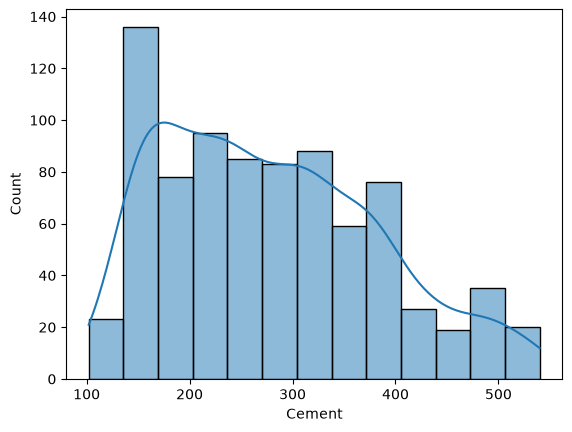

Cement skewness : 0.5104507965724165


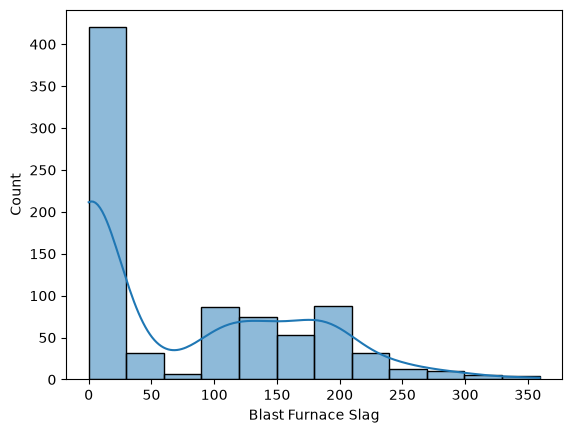

Blast Furnace Slag skewness : 0.725334885469053


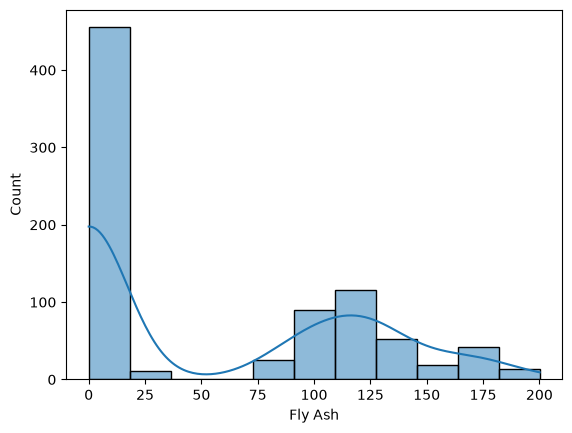

Fly Ash skewness : 0.5293627914753628


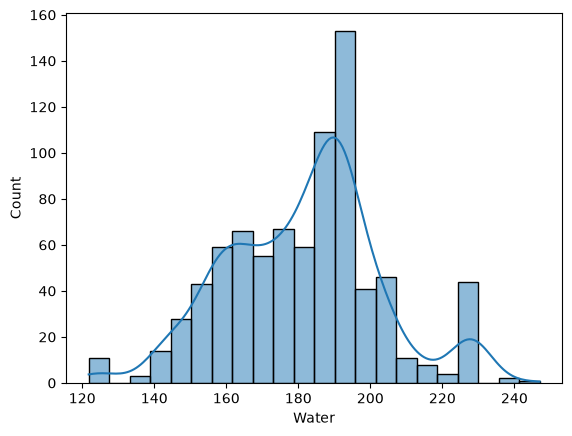

Water skewness : 0.04733959276732766


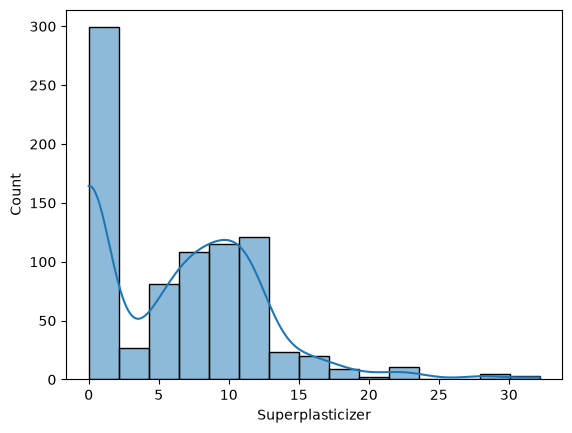

Superplasticizer skewness : 0.8611138983389793


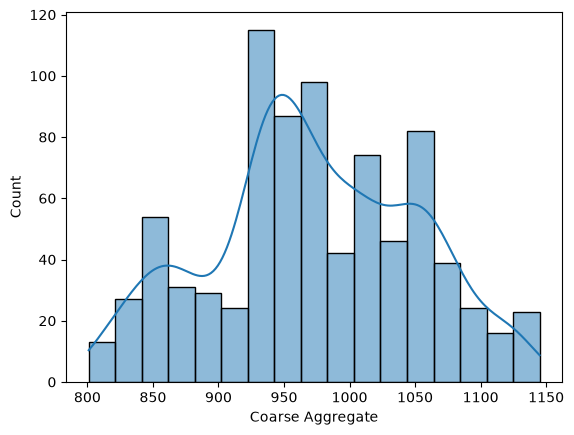

Coarse Aggregate skewness : -0.03830018148365835


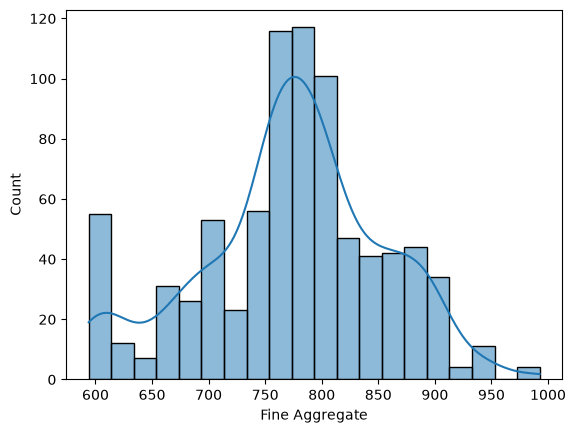

Fine Aggregate skewness : -0.24424282188402904


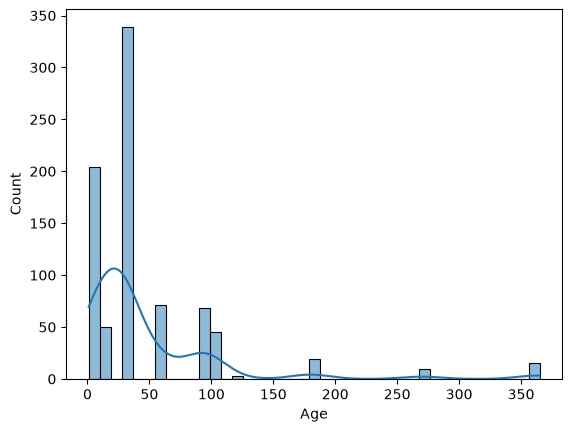

Age skewness : 3.270907493725208


In [37]:
for i in X_train.columns:
    sns.histplot(data=X_train, x=i, kde=True)
    plt.show()
    print(i, 'skewness :' ,X_train[i].skew())

# Apply Box-Cox transformation

In [51]:
pt = PowerTransformer(method='box-cox')

# We added 0.00001 to the X_train and X_test to avoid zeros cause box-cox does not allow zeros
X_train_bc = pt.fit_transform(X_train+0.000001)
X_test_bc = pt.transform(X_test+0.000001)

In [53]:
pd.DataFrame({'column':X_train.columns, 'lambda':pt.lambdas_}, )

,column,lambda
0,Cement,0.153049
1,Blast Furnace Slag,0.031295
2,Fly Ash,-0.034123
3,Water,0.888072
4,Superplasticizer,0.108879
5,Coarse Aggregate,1.115681
6,Fine Aggregate,1.789591
7,Age,0.063010


In [58]:
X_train_bc = pd.DataFrame(X_train_bc, columns=X_train.columns)

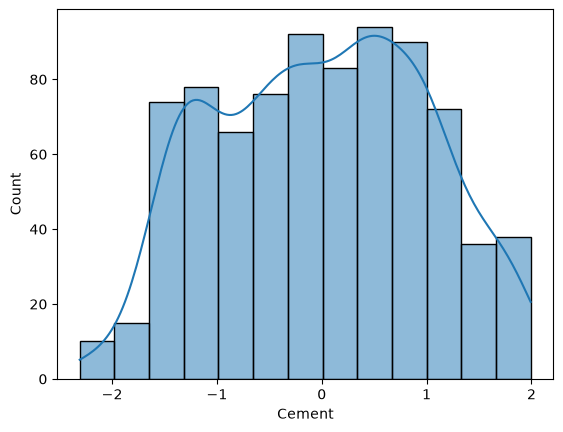

Cement : -0.01793218252208887


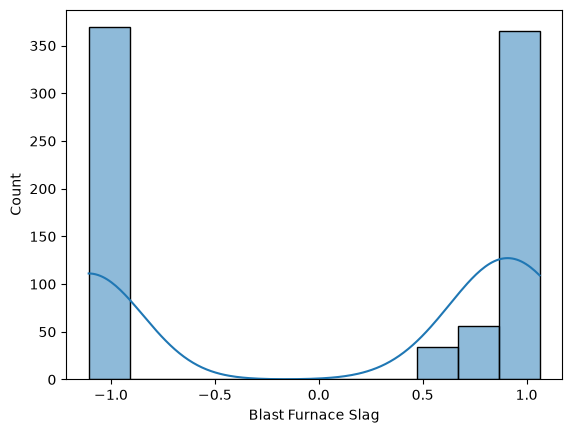

Blast Furnace Slag : -0.1920500391794457


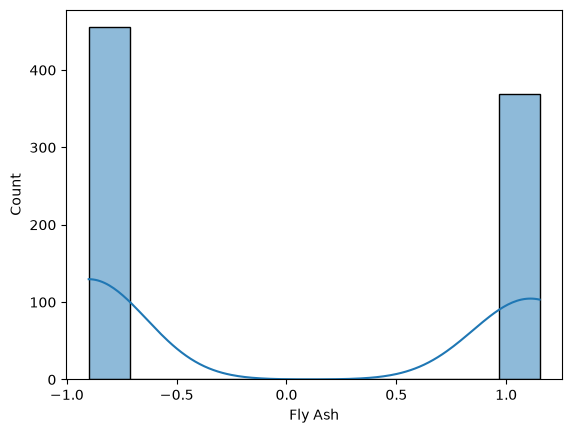

Fly Ash : 0.211280894817742


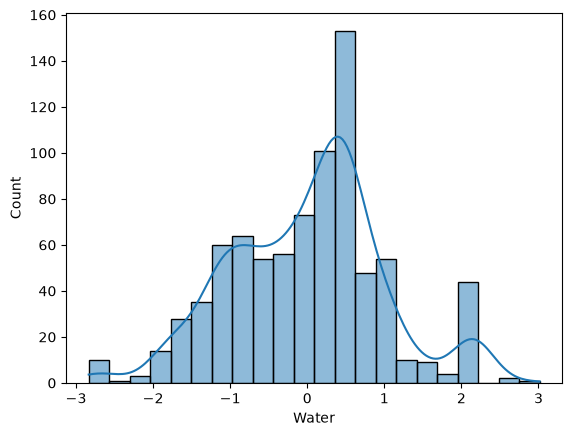

Water : 0.004557296603438224


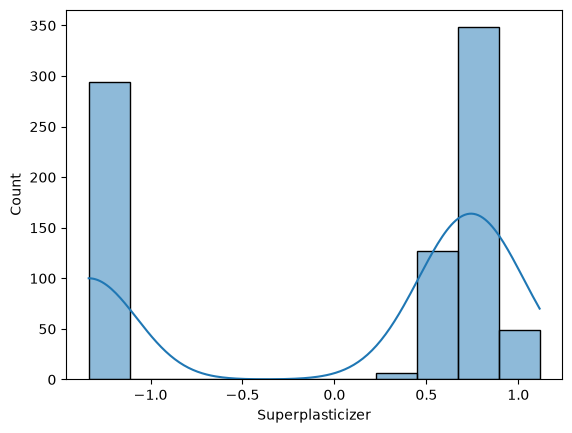

Superplasticizer : -0.5686082784297098


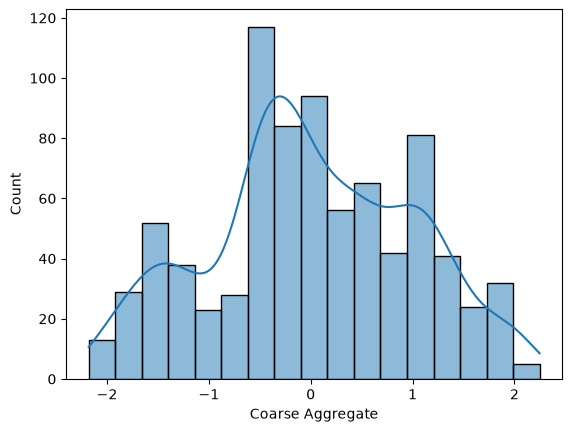

Coarse Aggregate : -0.019232414171649833


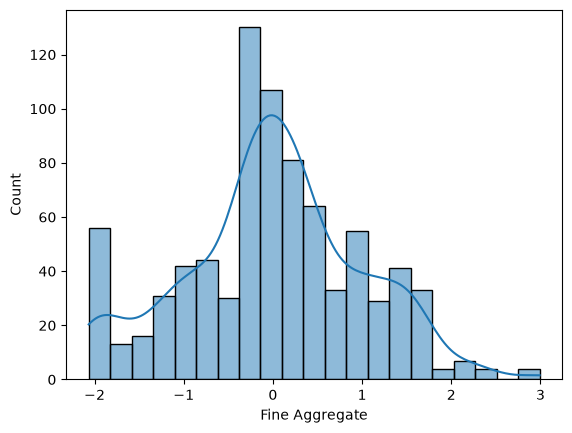

Fine Aggregate : -0.012542492861185198


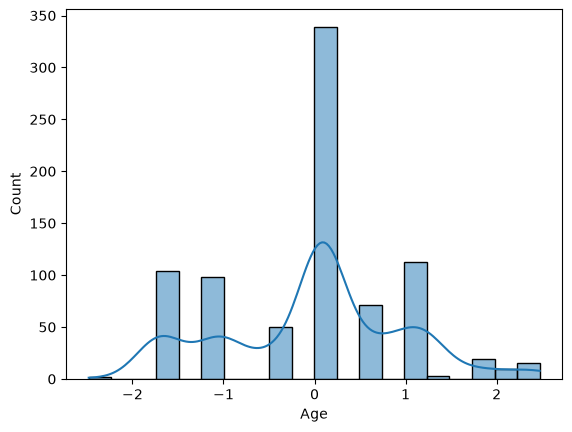

Age : -0.007574674618562752


In [65]:
for i in X_train_bc.columns:
    sns.histplot(data=X_train_bc, x=i, kde=True)
    plt.show()
    print(i, ':', X_train_bc[i].skew())

### There are significant difference between raw data distribution and box-cox transformed data distribution

# Apply Yeo-Jonson Transformation

In [75]:
yj = PowerTransformer()

In [76]:
# No need to add 0.0001 cause Yeo-Jonson supports zeros
X_train_yj = yj.fit_transform(X_train)
X_test_yj = yj.transform(X_test)

In [77]:
#Lest compare lambda values of box-cox and Yeo-Jonson
pd.DataFrame({'boxcox lambda':pt.lambdas_,'yeo-jonson lambda': yj.lambdas_}, index=X_train.columns)

,boxcox lambda,yeo-jonson lambda
Cement,0.153049,0.150260
Blast Furnace Slag,0.031295,0.038667
Fly Ash,-0.034123,-0.141876
Water,0.888072,0.887369
Superplasticizer,0.108879,0.293603
Coarse Aggregate,1.115681,1.115900
Fine Aggregate,1.789591,1.790678
Age,0.063010,0.016397


There are some columns have big diff in lambdas!!  
Lets check dustribution after yeo-jonson transformation

In [78]:
X_train_yj = pd.DataFrame(X_train_yj, columns=X_train.columns)
X_train_yj

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,1.650593,-1.076487,-0.898159,0.500146,-1.248187,-0.464028,-0.674132,0.088917
1,0.955079,-1.076487,-0.898159,0.221283,-1.248187,0.851069,-0.229380,0.088917
2,0.380429,0.957906,-0.898159,1.491625,0.307171,-0.981708,-0.656444,0.088917
3,-0.117399,-1.076487,1.115684,0.337596,0.335731,0.726632,-0.233057,-1.679702
4,1.768145,-1.076487,-0.898159,0.870452,-1.248187,1.984729,-1.870562,1.136340
...,...,...,...,...,...,...,...,...
819,-0.117399,-1.076487,1.115684,0.337596,0.248327,0.726632,-0.233057,0.705486
820,1.027987,-1.076487,-0.898159,0.221283,-1.248187,-0.078879,-0.167934,-2.285094
821,-1.506009,-1.076487,1.227034,-1.094063,1.472709,-0.374286,0.871611,0.088917
822,-0.241965,1.389959,-0.898159,0.207314,-1.248187,-0.392241,-1.321339,0.088917


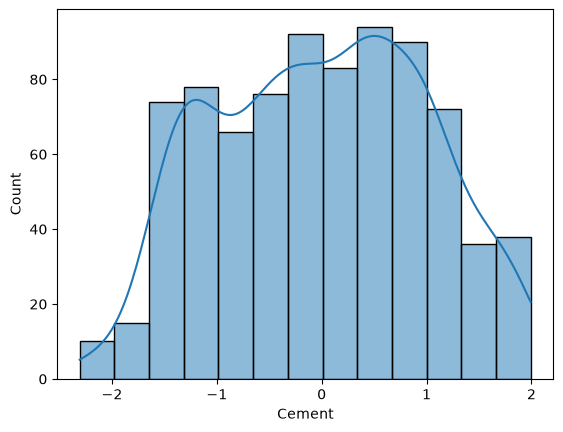

-0.017541103694575462


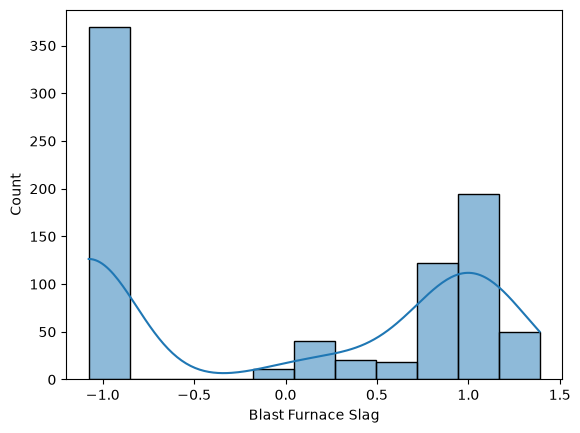

-0.05867106013916002


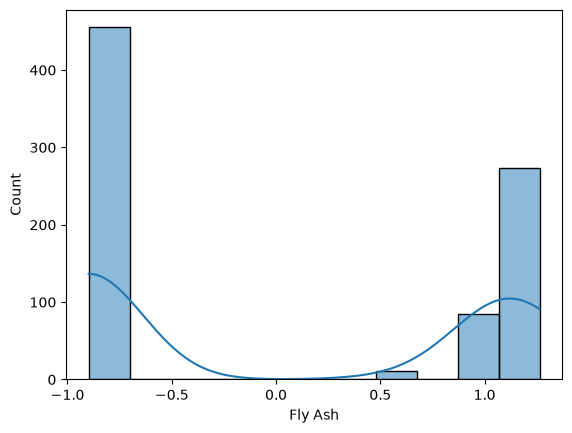

0.22466822363221595


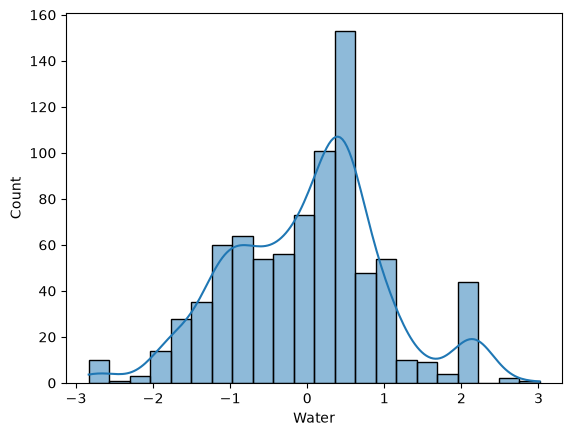

0.004530080016078511


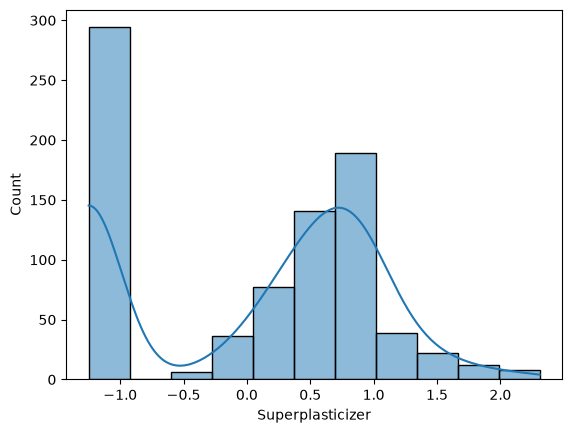

-0.17491677784209975


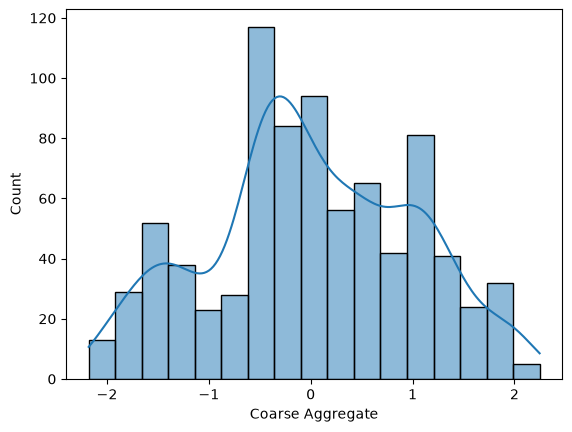

-0.019216030835716


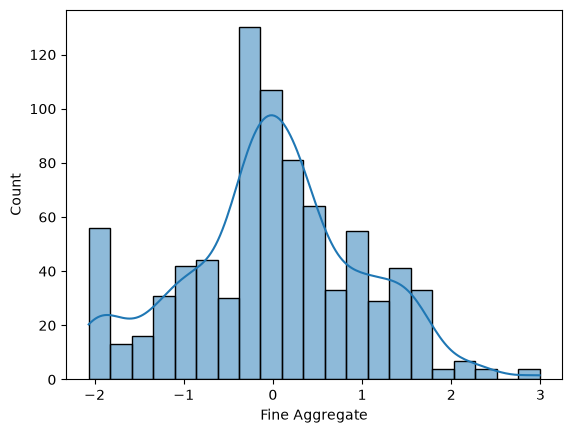

-0.012526937582247882


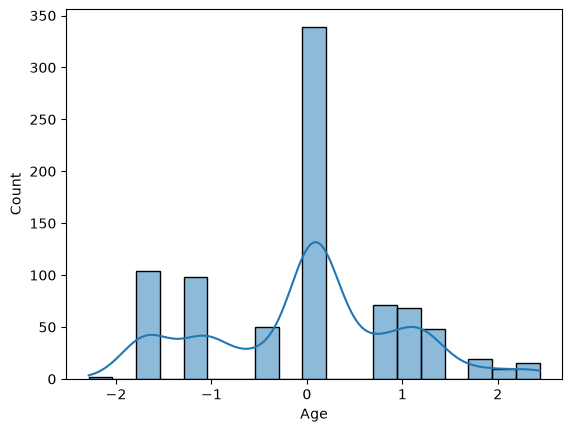

-0.002116486351199


In [81]:
for i in X_train_yj.columns:
    sns.histplot(data=X_train_yj, x=i, kde=True)
    plt.show()
    print(X_train_yj[i].skew())

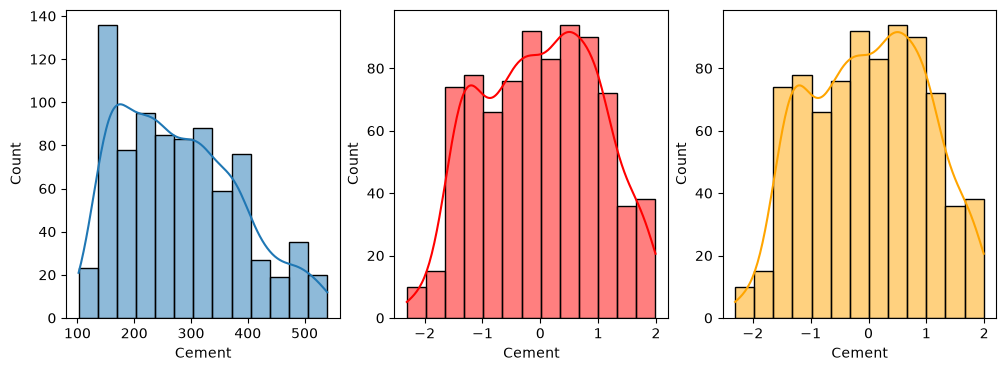

Raw skewness: 0.5104507965724165,             After Box-Cox: -0.01793218252208887,         After Yeo Jonson-0.017541103694575462


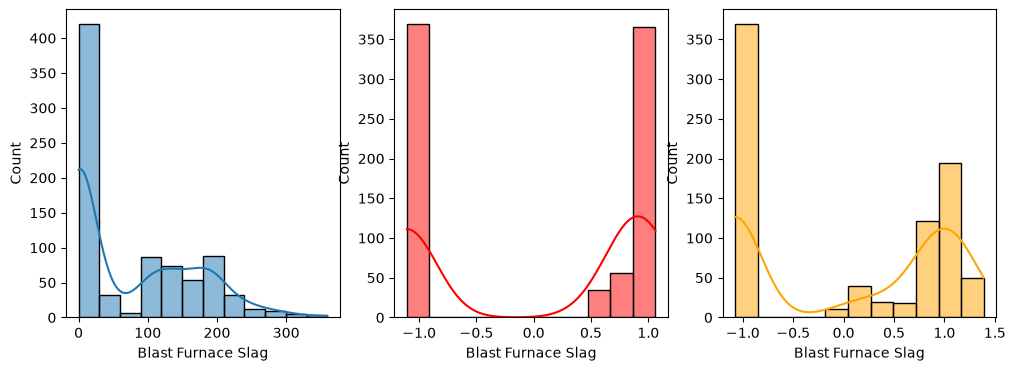

Raw skewness: 0.725334885469053,             After Box-Cox: -0.1920500391794457,         After Yeo Jonson-0.05867106013916002


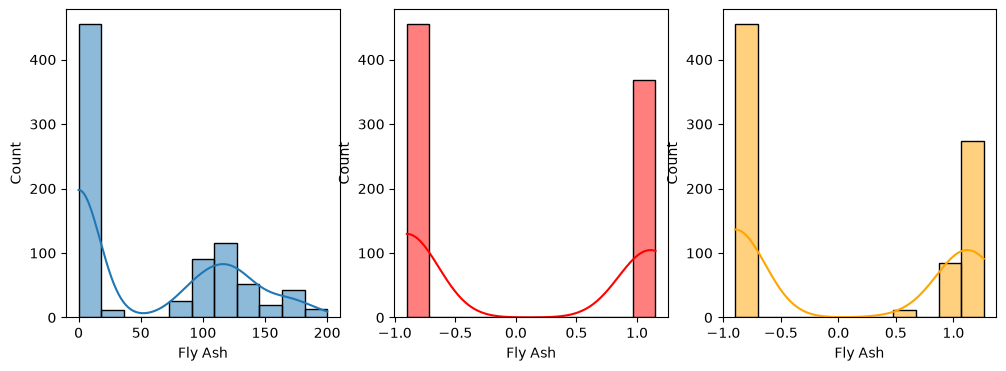

Raw skewness: 0.5293627914753628,             After Box-Cox: 0.211280894817742,         After Yeo Jonson0.22466822363221595


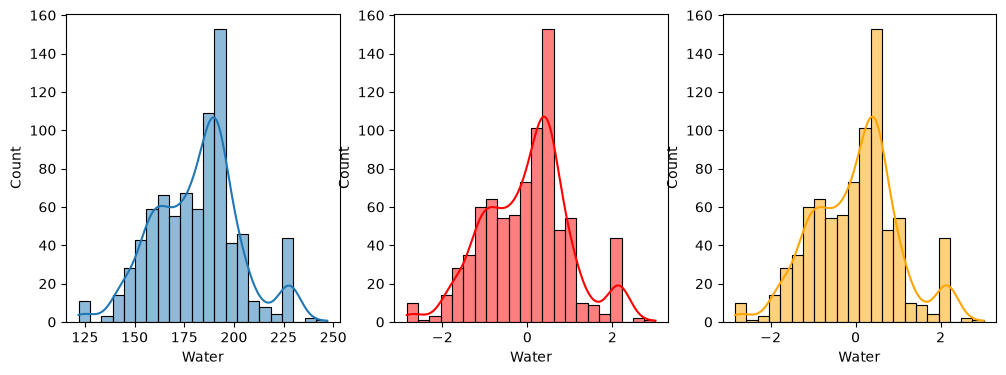

Raw skewness: 0.04733959276732766,             After Box-Cox: 0.004557296603438224,         After Yeo Jonson0.004530080016078511


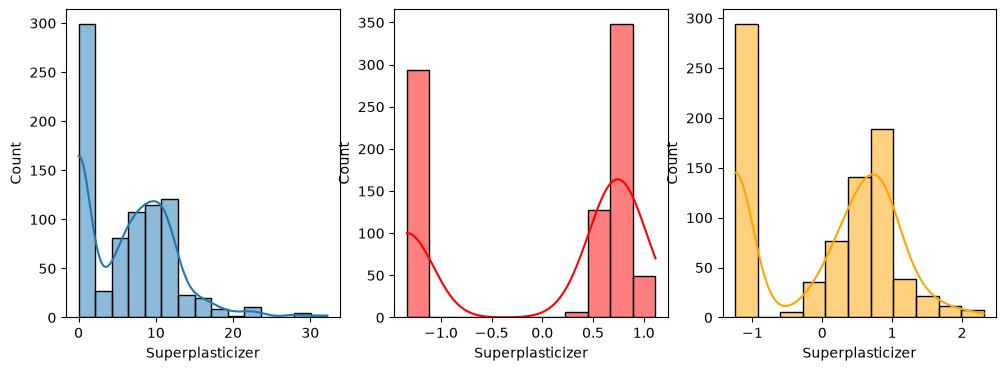

Raw skewness: 0.8611138983389793,             After Box-Cox: -0.5686082784297098,         After Yeo Jonson-0.17491677784209975


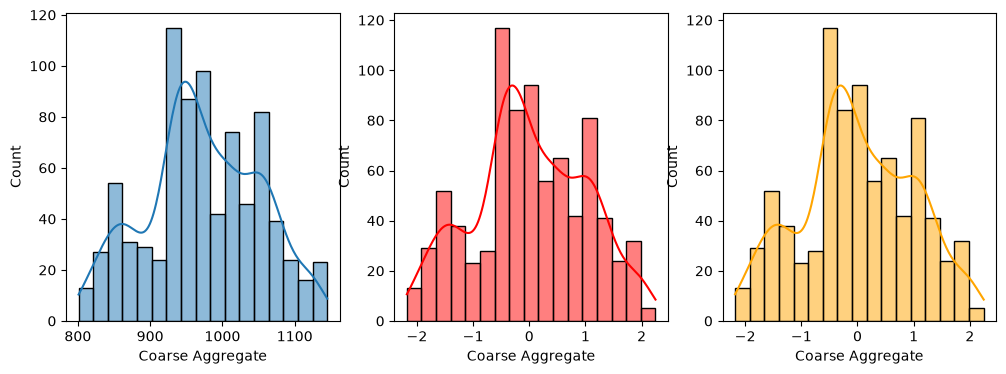

Raw skewness: -0.03830018148365835,             After Box-Cox: -0.019232414171649833,         After Yeo Jonson-0.019216030835716


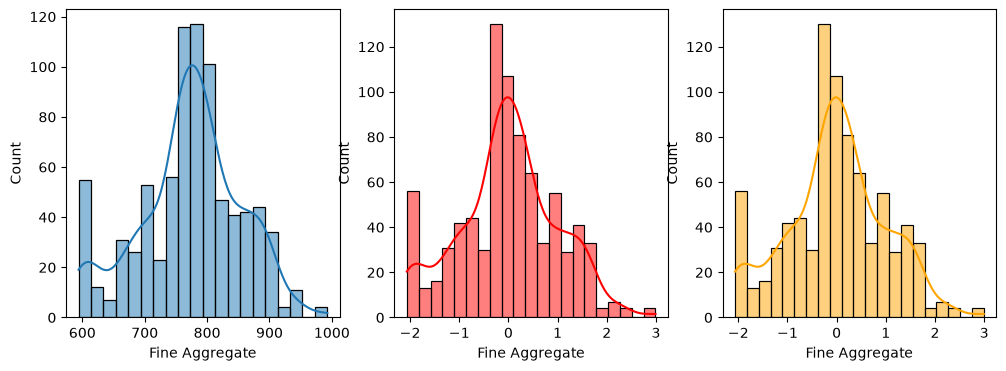

Raw skewness: -0.24424282188402904,             After Box-Cox: -0.012542492861185198,         After Yeo Jonson-0.012526937582247882


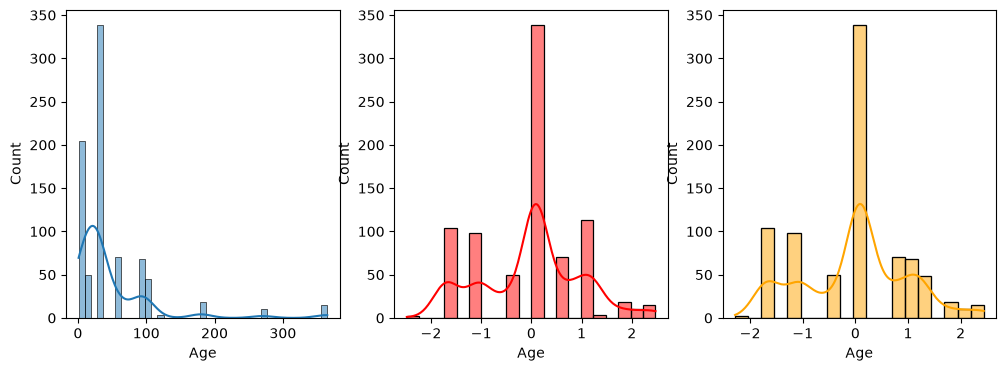

Raw skewness: 3.270907493725208,             After Box-Cox: -0.007574674618562752,         After Yeo Jonson-0.002116486351199


In [90]:
#lets chack side by side
# raw <-> after box-cox <-> after yeo-jonson
for i in X_train.columns:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=X_train, x=i, ax=axes[0], kde=True)
    sns.histplot(data=X_train_bc, x=i, ax=axes[1], kde=True, color='red')
    sns.histplot(data=X_train_yj, x=i, ax=axes[2], kde=True, color='orange')
    plt.show()
    print(f'Raw skewness: {X_train[i].skew()},             After Box-Cox: {X_train_bc[i].skew()},         After Yeo Jonson{X_train_yj[i].skew()}')

# Box-Cox <<<< Yeo-Jonson